## Importing Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

## Load the Data

In [3]:
mnist = fetch_openml('mnist_784', version=1)
X = pd.DataFrame(mnist.data)
y = mnist.target.astype(int)

In [6]:
## Data overview
print("Shape of features:", X.shape)  ## (70000, 784)
print("Shape of target:", y.shape)     ## (70000,)

Shape of features: (70000, 784)
Shape of target: (70000,)


## Data Visualization: Displaying Random Images

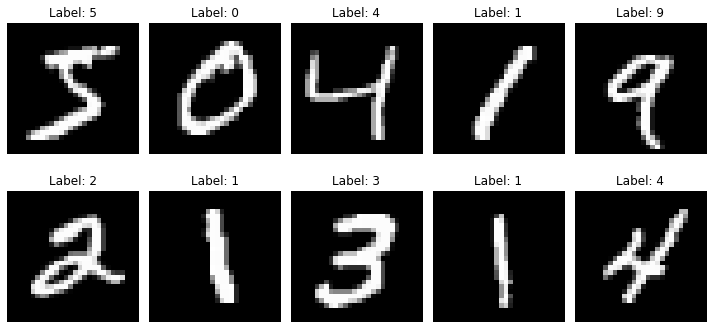

In [7]:
def plot_random_images(images, labels, n=10):
    plt.figure(figsize=(10, 5))
    for i in range(n):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

## Display random images
plot_random_images(X.to_numpy(), y.to_numpy())

## Split the Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Train the XGBoost Model

In [9]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

## Make Predictions

In [11]:
# Evaluate the Model on Training Data
y_train_pred = xgb_model.predict(X_train)
print("Train Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("\nTrain Classification Report:")
print(classification_report(y_train, y_train_pred))

# Evaluate the Model on Test Data
y_test_pred = xgb_model.predict(X_test)
print("Test Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred))

Train Confusion Matrix:
[[5560    0    0    0    0    0    0    0    0    0]
 [   0 6277    0    0    0    0    0    0    0    0]
 [   0    0 5610    0    0    0    0    0    0    0]
 [   0    0    0 5708    0    0    0    0    0    0]
 [   0    0    0    0 5529    0    0    0    0    0]
 [   0    0    0    0    0 5040    0    0    0    0]
 [   0    0    0    0    0    0 5480    0    0    0]
 [   0    0    0    0    0    0    0 5790    0    0]
 [   0    0    0    0    0    0    0    0 5468    0]
 [   0    0    0    0    0    0    0    0    0 5538]]

Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5560
           1       1.00      1.00      1.00      6277
           2       1.00      1.00      1.00      5610
           3       1.00      1.00      1.00      5708
           4       1.00      1.00      1.00      5529
           5       1.00      1.00      1.00      5040
           6       1.00      1.00   

## Hyperparameter Tuning with GridSearchCV

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), 
                           param_grid, cv=3, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters and score from Grid Search
print("Best Parameters from Grid Search:")
print(grid_search.best_params_)
print("Best Cross-Validation Score:")
print(grid_search.best_score_)

## Make predictions with the best model

In [ ]:
best_model = grid_search.best_estimator_
y_test_pred_best = best_model.predict(X_test)
print(y_test_pred_best)